#### Loading dataset and filtering it

In [ ]:
%pip install -r requirements.txt

In [2]:
import pandas as pd
from bertopic import BERTopic

c:\Users\wh1ww\VsCodeProjects\raisy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Reading csv 
df = pd.read_csv(r'dataset/datasetA.csv')
#Checking first 5 rows
df.head()

,title,link,date,source,number_of_characters_title,number_of_words_title,day_of_week,month,year,quarter,is_weekend,classes_str
0,Google’s AI is the ‘worst’ for stealing conten...,https://news.google.com/rss/articles/CBMipgFBV...,2025-09-11,Fortune,74,13,Thursday,September,2025,3,False,Sentiment (Positive / Negative Feelings); Huma...
1,Powering the Next Wave of Enterprise Innovatio...,https://news.google.com/rss/articles/CBMitgFBV...,2025-09-11,Silicon Canals,106,16,Thursday,September,2025,3,False,"Creativity, Expression & Identity; Work, Jobs ..."
2,AI a ‘strategic necessity’ law lecturer says,https://news.google.com/rss/articles/CBMiiAFBV...,2025-09-11,qlsproctor.com.au,64,9,Thursday,September,2025,3,False,"Society, Ethics & Culture"
3,Datacom sees AI agents as pivotal to legacy ap...,https://news.google.com/rss/articles/CBMirAFBV...,2025-09-11,ARNnet,70,12,Thursday,September,2025,3,False,"Routine, Lifestyle & Behavior"
4,"Student Blog: Startups, AI, and Lessons from S...",https://news.google.com/rss/articles/CBMijwFBV...,2025-09-11,The University of Queensland,85,13,Thursday,September,2025,3,False,"Learning, Knowledge & Education"


In [4]:
#Selecting just the title and classes_str columns. 
keyData = df[['title', 'classes_str']]
#Checking nulls 
keyData.isna().sum()

title          0
classes_str    0
dtype: int64

In [5]:
#Filtering the df so it only selects rows where the classes_str value contains 'Learning, Knowledge & Education'
df2 = keyData[keyData['classes_str'].str.contains('Learning, Knowledge & Education', case=False)]
df2.head()

,title,classes_str
4,"Student Blog: Startups, AI, and Lessons from S...","Learning, Knowledge & Education"
16,West Alabama school district looks to strength...,"Human Roles; Learning, Knowledge & Education; ..."
24,CEO: Proposed data center in College Station f...,"Learning, Knowledge & Education"
25,Maine Monitor: ‘Building the plane as we’re fl...,"Learning, Knowledge & Education"
42,Singtel to accelerate employees' AI upskilling...,"Work, Jobs & Economy; Learning, Knowledge & Ed..."


#### Word Frequency

In [6]:
#BERTopic only reads lists so i did this
docs = df2["title"].tolist()
print(len(docs))

1946


In [ ]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

Counter({'dog': 2, 'run': 2, 'fast': 1})


In [13]:
word_freq = Counter()

for text in docs:
    doc = nlp(text)
    word_freq.update(
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    )

print(word_freq.most_common(10))

[('ai', 1616), ('artificial', 454), ('intelligence', 454), ('study', 355), ('education', 323), ('university', 232), ('learning', 212), ('school', 194), ('training', 192), ('student', 191)]


#### Topic Modeling 

In [6]:
#pre making embeddings
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(docs)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 382.59it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [62]:
import numpy as np
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

# np.random.seed(42)

# umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.1, metric="cosine", random_state=42)

hdbscan_model = HDBSCAN(
    min_cluster_size=25,   # increase for fewer topics
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

representation_model = KeyBERTInspired()
topic_model = BERTopic(embedding_model=embedding_model, representation_model=representation_model, hdbscan_model = hdbscan_model)
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

# topic_model.reduce_topics(docs, nr_topics=15)
tm = topic_model.get_topic_info()
tm


,Topic,Count,Name,Representation,Representative_Docs
0,-1,599,-1_ai_education_learning_students,"[ai, education, learning, students, intelligen...",[The Complete Guide to Using AI in the Educati...
1,0,304,0_ai_learning_education_intelligence,"[ai, learning, education, intelligence, curric...",[AI in the classroom: How China is bringing ar...
2,1,196,1_ai_curriculum_education_intelligence,"[ai, curriculum, education, intelligence, acad...",[New Mexico university to offer state's first ...
3,2,188,2_ai_intelligence_learning_knowledge,"[ai, intelligence, learning, knowledge, artifi...",[Application and ethical implication of genera...
4,3,150,3_ai_intelligence_stanford_artificial,"[ai, intelligence, stanford, artificial, knowl...",[AI adoption linked to 13% decline in jobs for...
5,4,91,4_ai_intelligence_learning_students,"[ai, intelligence, learning, students, stanfor...",[Study says AI chatbots need to fix suicide re...
6,5,75,5_ai_learning_university_teach,"[ai, learning, university, teach, knowledge, s...","[Like Humans, AI Can Jump to Conclusions, Moun..."
7,6,72,6_ai_education_learning_academy,"[ai, education, learning, academy, educators, ...","[Microsoft Pledges $4B for AI Education, Teach..."
8,7,70,7_ai_learning_intelligence_education,"[ai, learning, intelligence, education, teachi...",[Balancing AI and human creativity: Industry l...
9,8,59,8_ai_creativity_tech_microsoft,"[ai, creativity, tech, microsoft, writers, tra...",[A federal judge sides with Anthropic in lawsu...


In [49]:
with open("Topics.txt", 'w') as f:
    for i in range(1, 7):
        f.write(f"Topic Name: {tm['Name'].iloc[i]} \n")
        f.write(f"Document Count For Topic: {tm['Count'].iloc[i]} \n")
        f.write(f"Representation and Weights: \n")
        for tup in topic_model.get_topic(i):
            f.write(f"({tup[0]}, {float(tup[1]):.2f}) \n")
        f.write("Representative Docs: \n")
        for doc in tm['Representative_Docs'].iloc[i]:
            f.write(f"{doc} \n")
        f.write("\n")

#### Sentiment Analysis

In [50]:
docDf = topic_model.get_document_info(docs)
docDf.head()

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,"Student Blog: Startups, AI, and Lessons from S...",1,1_ai_education_intelligence_academic,"[ai, education, intelligence, academic, advanc...",[Bringing the best of AI to college students f...,ai - education - intelligence - academic - adv...,1.000000,False
1,West Alabama school district looks to strength...,0,0_ai_learning_education_intelligence,"[ai, learning, education, intelligence, curric...",[AI in the classroom: How China is bringing ar...,ai - learning - education - intelligence - cur...,0.677765,False
2,CEO: Proposed data center in College Station f...,-1,-1_ai_education_learning_students,"[ai, education, learning, students, intelligen...",[Morgan State University Collaborates with Ama...,ai - education - learning - students - intelli...,0.000000,False
3,Maine Monitor: ‘Building the plane as we’re fl...,0,0_ai_learning_education_intelligence,"[ai, learning, education, intelligence, curric...",[AI in the classroom: How China is bringing ar...,ai - learning - education - intelligence - cur...,1.000000,False
4,Singtel to accelerate employees' AI upskilling...,3,3_ai_intelligence_stanford_artificial,"[ai, intelligence, stanford, artificial, knowl...",[Study shows what jobs are most at risk as AI ...,ai - intelligence - stanford - artificial - kn...,0.751469,False


#### Plot

In [ ]:
import re

def word_freq_for_topic(topic_id, docs, topics):
    topic_docs = [doc for doc, t in zip(docs, topics) if t == topic_id]
    
    words = []
    for doc in topic_docs:
        words.extend(re.findall(r"\b\w+\b", doc.lower()))
    
    return Counter(words)

freqs = word_freq_for_topic(6, docs, topics)
freqs.most_common(20)

[('ai', 73),
 ('training', 48),
 ('to', 29),
 ('for', 25),
 ('microsoft', 20),
 ('in', 18),
 ('and', 17),
 ('with', 14),
 ('the', 13),
 ('free', 12),
 ('education', 12),
 ('s', 10),
 ('google', 10),
 ('new', 10),
 ('on', 9),
 ('openai', 7),
 ('of', 7),
 ('a', 7),
 ('learning', 7),
 ('teachers', 7)]

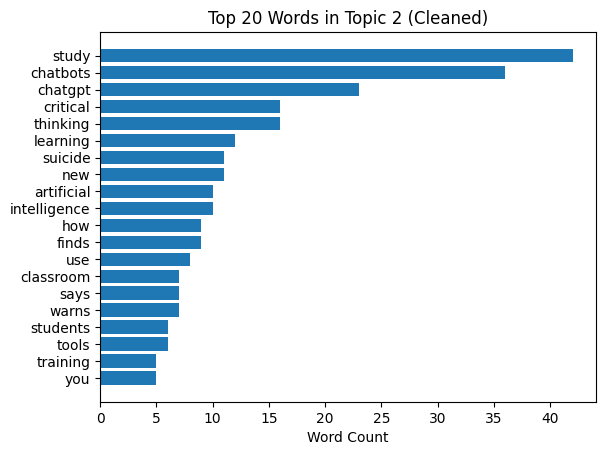

In [74]:
import matplotlib.pyplot as plt
stopwords = {"the", "and", "of", "to", "in", "for", "on", "with", "a", "an", "by"}

freqs_clean = Counter({
    word: count
    for word, count in freqs.items()
    if word not in stopwords and len(word) > 2
})

words, counts = zip(*freqs_clean.most_common(20))

plt.figure()
plt.barh(words, counts)
plt.xlabel("Word Count")
plt.title("Top 20 Words in Topic 2 (Cleaned)")
plt.gca().invert_yaxis()
plt.show()

##### Vader Sentiment Analysis (Rule Based)

In [51]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
def sentiment_scores(text):
    sid_obj = SentimentIntensityAnalyzer()
    sentiment_dict = sid_obj.polarity_scores(text)
    return sentiment_dict

def getSentiment(compound):
    if compound >= 0.15:
        return "Positive"
    elif compound <= -0.15:
        return "Negative"
    else:
        return "Neutral"

In [76]:
topic1 = docDf[docDf['Topic'] == 4]
v_sent_count = {
    "Negative": 0,
    "Neutral": 0,
    "Positive": 0
}

with open("Vader Sentiment Analysis.txt", "w", encoding="utf-8", errors="replace") as f:
    for doc in topic1['Document']:
        f.write(f"Article Title: {doc} \n")
        scores = sentiment_scores(doc)
        f.write(f"Score: {scores['compound']} \n")
        f.write(f"Sentiment: {getSentiment(scores['compound'])} \n")
        v_sent_count[getSentiment(scores['compound'])] += 1
        f.write("\n")

v_sent_count

{'Negative': 35, 'Neutral': 26, 'Positive': 21}

##### Text Blob Sentiment Analysis (Machine Learning Based)

In [ ]:
from textblob import TextBlob
def get_sentiment_label (polarity):
    if polarity > 0.2:
        return 'Positive'
    elif polarity < -0.2:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
tb_sent_count = {
    "Negative": 0,
    "Neutral": 0,
    "Positive": 0
}

with open("Textblob Sentiment Analysis.txt", "w", encoding="utf-8", errors="replace") as f:
    for doc in topic1['Document']:
        f.write(f"Article Title: {doc} \n")
        docBlob = TextBlob(doc)
        polarity = docBlob.sentiment[0]
        sent = get_sentiment_label(polarity)
        f.write(f"Polarity: {polarity} \n")
        f.write(f"Sentiment: {sent} \n")
        tb_sent_count[sent] += 1
        f.write("\n")

tb_sent_count

{'Negative': 93, 'Neutral': 204, 'Positive': 32}